# Plots for the paper

In [172]:
import warnings
warnings.filterwarnings('ignore')

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ase.io import read
import matplotlib.pylab as pylab
from ase.units import kB
from flonacomldft.utils.io_utils import save_pickle_file, load_pickle_file, load_csv_file, get_project_path

size=5
params = {'legend.fontsize': size,
          'figure.figsize': (5.5*3, 5.5),
         'axes.labelsize': size,
         'axes.titlesize': size,
         'xtick.labelsize': size,
         'ytick.labelsize': size}

pylab.rcParams.update(params)

#https://github.com/garrettj403/SciencePlots
#https://www.theochem2.ruhr-uni-bochum.de/tc/software/runner.html.en
#https://github.com/mir-group/nequip


In [53]:
# get minima structure configurations
from flonacomldft.utils.silver_isomers_utils import get_molecule_isomer_minima
from flonacomldft.utils.plots import plot_energy_surface, plot_energy_histogram
from ase.visualize.plot import plot_atoms
from flonacomldft.internal_coordinates import Coordinates_mapping

# load adaptive simulations
from flonacomldft.utils.io_utils import load_pickle_file
from flonacomldft.utils.plots import set_plot_sequential_data, load_ag6_image
from flonacomldft.utils.diagnostics import avg_windows

ag6_is0 = get_molecule_isomer_minima(name="is0")
ag6_is1 = get_molecule_isomer_minima(name="is1")

ag6_is0.center()
ag6_is1.center()

ag6_is0.translate([4, 0, 0])
ag6_is1.translate([11, 7, 7])

In [54]:
# 300 K results
# path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/1-adaptive/results_2"
# simulations = ["results_adaptive_is0_25072550/adaptive_sampling_is0_25072550.pkl",
#               "results_adaptive_is1_25072551/adaptive_sampling_is1_25072551.pkl"]

# 350 K results
path = "/mnt/home/amolina/ceph/adaptive-350/adaptive-dft"
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = [#'2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                     '2-adaptive-mlp/results_adaptive_is0_29525786/adaptive_sampling_is0_29525786.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

adaptives_dft = {i: load_pickle_file(adaptive_dft_path[i], path) for i in range(0, 2)}
adaptives_mlp = {i: load_pickle_file(adaptive_mlp_path[i], path) for i in range(0, 2)}

In [55]:
def cvs_from_adaptive(adaptive, isomer_id=0, etype='dft'):

    coord_mapping = Coordinates_mapping(etype='dft')

    xs = torch.cat(adaptive['xs']).detach()

    xs_flatten = xs.reshape(-1, 12)

    isomers_mask = torch.cat(adaptive['isomers']).reshape(-1, 1)

    xs_is0 = []

    for isomer, x in zip(isomers_mask, xs_flatten):

        if (isomer[0]==isomer_id).item():
            xs_is0.append(x)

    xs_is0 = torch.stack(xs_is0)

    cvs_is0 = coord_mapping.get_collective_variables_from_real_centered(xs_is0, isomer=isomer_id)

    return cvs_is0

In [56]:
def load_proposal_from_flow(path, n_run, n_chains, n_steps, isomer=None):

    ag6_proposals = []
    for chain in range(n_chains):
        for step in range(n_steps):
            try:
            #print("ag6_{:d}_{:d}_{:d}.out".format(n_run, step, chain))
                ag6_proposals.append(read("{:s}DFTAdaptive/ag6_{:d}_{:d}_{:d}.out".format(path, n_run, step, chain)))
            except:
                continue
    coord_mapping = Coordinates_mapping()

    zmat = coord_mapping.get_internal_from_trajectory(ag6_proposals, isomer=isomer, temperature=350)
    xs = coord_mapping.get_real_centered_from_internal(zmat[:, :12], isomer=isomer, energies=zmat[:, 12])        
    
    return xs, zmat, ag6_proposals

def get_participation_ratio_from_dft_proposals(xs, us, model, kB, T):
    
    n_prop = xs.shape[0]
    
    log_weight = -us.squeeze()/(kB*T) + model.nll(xs)
    log_ratio = torch.logsumexp(2 * log_weight, dim=0) - 2 * torch.logsumexp(log_weight, dim=0)
    
    return torch.exp(-log_ratio) / n_prop 

def compute_part_ratios_per_adaptive(adaptive, path, isomer):

    part_ratios = []

    n_runs = 30#adaptive["args"]["n_runs"]
    n_chains = 20#adaptive["args"]["n_runs"]
    n_steps = 5#adaptive["args"]["n_steps"]

    for n_run in range(n_runs):
    
        model = adaptive["dict_flows_training"][n_run][0]['model']
        xs = load_proposal_from_flow(path, n_run, n_chains, n_steps, isomer)[0]

        part_ratio = get_participation_ratio_from_dft_proposals(xs[0].float(), xs[2].float(), model, kB, 300)
    
        part_ratios.append(part_ratio)
        
    mcmc_steps = list(range(0, n_runs*n_steps, n_steps))
        
    return torch.stack(part_ratios), mcmc_steps

In [150]:
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
import string

In [177]:
def plot_figure_1(plot_data, 
                    colors, 
                    linewidth=0.5, 
                    markersize=2, 
                    scattersize=1, 
                    figsize = (5.5*3, 5.5) ):

    keys = plot_data['keys']

    formatter = FormatStrFormatter('%.1f')
    
    fig, axs = plt.subplots(ncols=3, nrows=2, figsize=figsize)
    gs = axs[0, 0].get_gridspec()
    # remove the underlying axes
    for ax in axs[0:, 0]:
        ax.remove()
    
    axbig = fig.add_subplot(gs[0:, :1])

    
    #==== PLOT CVS
    idx_rand = torch.randint(0, plot_data['cvs'][keys[0]].shape[0], (plot_data['cvs']['MD'].shape[0],))
    for key in plot_data['cvs'].keys() :
        if key=='MD': 
            idx_rand = torch.arange(0, plot_data['cvs']['MD'].shape[0]) 
        axbig.scatter(plot_data['cvs'][key][:, 0][idx_rand].detach().numpy(), 
                        plot_data['cvs'][key][:, 1][idx_rand].detach().numpy(), 
                        c=colors[key], 
                        s=scattersize,
                        marker='x',
                        label=key)

    axbig.set_xlabel('Coordination number')
    axbig.set_ylabel('Radius of gyration')

    axbig.legend(loc='upper right')

    axbig.xaxis.set_major_locator(plt.MaxNLocator(3))
    axbig.yaxis.set_major_locator(plt.MaxNLocator(3))
    axbig.xaxis.set_major_formatter(formatter)
    axbig.yaxis.set_major_formatter(formatter)

    axbig.text(-0.3, 2.35, string.ascii_uppercase[0], transform=ax.transAxes, 
            weight='bold')
    
    #==== PLOT Isomer image

    l, b, h, w = .025, .15, .15, .075
    ax2 = fig.add_axes([l, b, w, h])
    ax2.imshow(load_ag6_image(plot_data['isomer']))
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_axis_off()

    #==== PLOT Free energy plot
    

    #==== PLOT energies histogram
    #sns.histplot(config['data'], label=label, color=config['color'], alpha=0.5)

    plot_energy_histogram(plot_data['energies'], 
                        ax=axs[0][1], 
                        bins=30, 
                        alpha=0.2, 
                        palette=colors,
                        hue_order=list(plot_data['energies'].keys())[::-1],
                        element='step',
                        legend=False,
                        linewidth=linewidth,
                        )
    axs[0][1].set_xlabel("Potential energy [e.V]")

    #==== PLOT acceptance ratio 

    for key in plot_data['accs'].keys():
        set_plot_sequential_data(plot_data['accs'][key], 
                             avg=True, 
                             window_size=25, 
                             color=colors[key], 
                             ax=axs[1][1], 
                             linewidth=linewidth, 
                             alpha=0.1,
                             label=key)

    #axs[1][1].legend()
    axs[1][1].set_ylabel("Acceptance ratio")
    axs[1][1].set_xlabel("MCMC steps")

    #===== PLOT RHAT

    markers = ['o', 'x', '^']
    linestyles = ['dashed', 'dotted', '-']

    for key in plot_data['rhat'].keys():
        for i in range(plot_data['rhat'][key][0].shape[-1]):
            axs[1][2].plot(plot_data['rhat'][key][1], 
                            plot_data['rhat'][key][0][:, i], 
                            linestyle=linestyles[i], 
                            marker=markers[i],
                            markersize=markersize,
                            linewidth=linewidth,
                            color=colors[key], 
                            label=plot_data['rhat'][key][2][i])
        axs[1][2].axhline(1, c='k', ls='--', linewidth=linewidth)
        axs[1][2].axhline(1.01, c='grey', ls='--', linewidth=linewidth)
        axs[1][2].set_xlabel('Iteration')
        axs[1][2].set_ylabel(r'$\hat{R}$')

    colors = ["k"]*3
    patches = [ axs[1][2].plot([],[], marker=markers[i], linestyle=linestyles[i], linewidth=linewidth, markersize=markersize, color=colors[i], 
                label="{:s}".format(plot_data['rhat'][key][2][i]) )[0]  for i in range(len(plot_data['rhat'][key][2])) ]
    axs[1][2].legend(handles=patches)

    #for ax in axs.ravel()[:-1]:
    #    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    #    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    #    ax.xaxis.set_major_formatter(formatter)
    #    ax.yaxis.set_major_formatter(formatter)

# Add title

    #fig.suptitle("Ab-initio flowMC - Isomer {:d}".format(plot_data['isomer']), )
    #             #fontsize=48)
    #fig.tight_layout()
    #fig.subplots_adjust(top=0.92)

In [58]:
def get_info_from_adaptive(adaptive, path, isomer):
    
    accs = torch.cat(adaptive['accs']).mean(axis=1)
    us = torch.cat(adaptive['us'])
    xs = torch.cat(adaptive['xs'])

    cvs = cvs_from_adaptive(adaptive, isomer_id=isomer)

    #part_ratios = compute_part_ratios_per_adaptive(adaptive, path, isomer)

    flow_models = adaptive["dict_flows_training"]

    nlls = []
    for i in range(30):
        nll = []
        for x in adaptive['xs'][i]:
            nll.append(flow_models[i][0]['model'].nll(x))
        nll = torch.stack(nll)
        nlls.append(nll)

    to_return = {
        'accs' : accs,
        'us' : us,
        'nlls' : nlls,
        #'part_ratios' : part_ratios,
        'cvs' : cvs,
    }

    return to_return

## Adaptive one isomer.

In [113]:
keys = ['ab-flowMC w.o NP', 'ab-flowMC', 'MD'] #Fix name
color_keys = dict(zip(keys, ['blue', 'orange', 'green']))

In [114]:
adaptives_is0 = {key: load_pickle_file(adaptive, path) for key, adaptive in zip(keys, [adaptive_dft_path[0], adaptive_mlp_path[0]])}
adaptives_is1 = {key: load_pickle_file(adaptive, path) for key, adaptive in zip(keys, [adaptive_dft_path[1], adaptive_mlp_path[1]])}

In [115]:
#adaptive_path_is0 = {keys[0]: adaptive_dft_path[0],
#                     keys[1]: adaptive_mlp_path[0]}
#
#adaptive_path_is1 = {keys[0]: adaptive_dft_path[1],
#                     keys[1]: adaptive_mlp_path[1]}

In [116]:
#adaptive_info_is0 = {key: get_info_from_adaptive(adaptives_is0[key], 
#                                                 path + '/' + adaptive_path_is0[key].split('/')[0] + '/' + adaptive_path_is0[key].split('/')[1] + '/', 
#                                                 0) for key in keys}

In [117]:
#adaptive_info_is1 = {key: get_info_from_adaptive(adaptives_is1[key], 
#                                                 path + '/' + adaptive_path_is1[key].split('/')[0] + '/' + adaptive_path_is1[key].split('/')[1] + '/', 
#                                                 1) for key in keys}

In [118]:
save_plot_data = "data_for_plots"
#save_pickle_file(adaptive_info_is0, 'ab-initio-flow-is0.pkl', get_project_path() + '/' + save_plot_data)
#save_pickle_file(adaptive_info_is1, 'ab-initio-flow-is1.pkl', get_project_path() + '/' + save_plot_data)

In [119]:
adaptive_info_is0 = load_pickle_file('ab-initio-flow-is0.pkl', get_project_path() + '/' + save_plot_data)
adaptive_info_is1 = load_pickle_file('ab-initio-flow-is1.pkl', get_project_path() + '/' + save_plot_data)

import copy

for i, key in enumerate(copy.deepcopy(adaptive_info_is0).keys()):
    adaptive_info_is0[keys[i]] = adaptive_info_is0[key]
    del adaptive_info_is0[key]

for i, key in enumerate(copy.deepcopy(adaptive_info_is1).keys()):
    adaptive_info_is1[keys[i]] = adaptive_info_is1[key]
    del adaptive_info_is1[key]

In [120]:
is0_md = load_csv_file('is0_flow_train.csv', get_project_path() + '/database/andersen/datasets')
is1_md = load_csv_file('is1_flow_train.csv', get_project_path() + '/database/andersen/datasets')

In [121]:
from flonacomldft.utils.diagnostics import R_hat
import pandas as pd

In [122]:
plot_data_is0 = {
    'isomer' : 0,
    'keys' : keys,
    'accs' : {key: adaptive_info_is0[key]['accs'] for key in keys if key != 'MD'},
    'us' : {key: adaptive_info_is0[key]['us'] for key in keys if key != 'MD'},
    'nlls' : {key: torch.cat(adaptive_info_is0[key]['nlls']) for key in keys if key != 'MD'},
    #'part_ratios' : {key: adaptive_info_is0[key]['part_ratios'] for key in keys},
    'energies' : {key: adaptive_info_is0[key]['us'].flatten().detach().numpy() for key in keys if key != 'MD'},
    'cvs' : {key: adaptive_info_is0[key]['cvs'] for key in keys if key != 'MD'},
    'rhat' : {key: R_hat(torch.cat((adaptive_info_is0[key]['cvs'].reshape(600, 50, 2), adaptive_info_is0[key]['us'].reshape(600, 50, 1)), dim=2).detach().numpy().transpose(1, 0, 2), 
                    labels=['Radius of gyration', 'Coordination number', 'Energy']) for key in keys if key != 'MD'}
}

plot_data_is0['cvs']['MD'] = is0_md[:, -2:]
plot_data_is0['energies']['MD'] = is0_md[:, 12]

In [123]:
plot_data_is1 = {
    'isomer' : 1,
    'keys' : keys,
    'accs' : {key: adaptive_info_is1[key]['accs'] for key in keys if key != 'MD'},
    'us' : {key: adaptive_info_is1[key]['us'] for key in keys if key != 'MD'},
    'nlls' : {key: torch.cat(adaptive_info_is1[key]['nlls']) for key in keys if key != 'MD'},
    #'part_ratios' : {key: adaptive_info_is1[key]['part_ratios'] for key in keys},
    'energies' : {key: adaptive_info_is1[key]['us'].flatten().detach().numpy() for key in keys if key != 'MD'},
    'cvs' : {key: adaptive_info_is1[key]['cvs'] for key in keys if key != 'MD'},
    'rhat' : {key: R_hat(torch.cat((adaptive_info_is1[key]['cvs'].reshape(600, 50, 2), adaptive_info_is1[key]['us'].reshape(600, 50, 1)), dim=2).detach().numpy().transpose(1, 0, 2),
                    labels=['Radius of gyration', 'Coordination number', 'Energy']) for key in keys if key != 'MD'}
}

plot_data_is1['cvs']['MD'] = is1_md[:, -2:]
plot_data_is1['energies']['MD'] = is1_md[:, 12]

In [124]:
path_to_save_figures = get_project_path() + '/figures/'

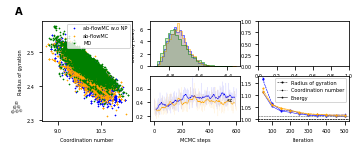

In [179]:
#%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
plot_figure_1(plot_data_is0, 
              color_keys,
              linewidth=0.5,
              markersize=1,
              scattersize=0.5,
              figsize=(5.5, 5.5/3)
              )
plt.savefig(path_to_save_figures+'figure_1_is0.png', dpi=300, facecolor='white', transparent=False)

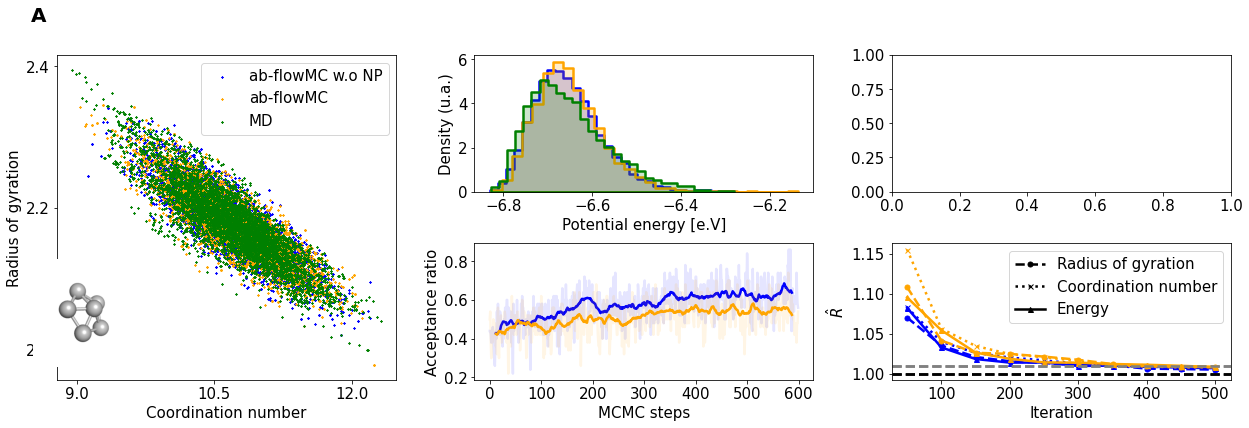

In [168]:
#%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
plot_figure_1(plot_data_is1, 
              color_keys,
              linewidth=2.5,
              markersize=5,
              scattersize=2,
              figsize=(6*3, 6)
              )
plt.tight_layout()
plt.savefig(path_to_save_figures+'figure_1_is1.png', dpi=300, facecolor='white', transparent=False)

# Figure 2

In [73]:
# simulation files
#mcmc_paths = ['5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl',
#             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134160/mixture_mcmc_dic_29134160.pkl',
#             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134161/mixture_mcmc_dic_29134161.pkl']

# load mcmc results
keys = ['ab-flowMM w.o NP', 'ab-flowMM']
color_keys = dict(zip(keys, ['blue', 'orange']))
mcmcs = {new_key: load_pickle_file('mcmcs_sims.pkl', get_project_path() + '/data_for_plots')[old_key] for old_key, new_key in zip(['Ab-initio flow MC w.o NP Mixture Model', 
        'Ab-initio flow MC Mixture Model'], keys)}

In [74]:
us = {key: mcmcs[key]['us'].flatten().detach() for key in keys}

In [75]:
cvs_mcmcs = {new_key: load_pickle_file('cvs_mcmcs.pkl', get_project_path() + '/data_for_plots')[old_key] for old_key, new_key in zip(['Ab-initio flow MC w.o NP Mixture Model', 
        'Ab-initio flow MC Mixture Model'], keys)}

In [76]:
from flonacomldft.models.mixture import Mixture

In [77]:
weights = torch.tensor([0.75, 0.25]).detach()
mixture_models = {}
for key, adaptives in zip(keys, [adaptives_dft, adaptives_mlp]):
    flow_models = []
    for i in range(2):
        flow_models.append(adaptives[i]['dict_flows_training'][-1][0]['model'])
    mixture_model = Mixture(flow_models, weights)
    mixture_models[key] = mixture_model

In [78]:
def get_data_proposals(n_samples, mixture_model):
    samples, isomers = mixture_model.sample(n_samples, return_mus=True)
    target_log_prob = lambda x: -mixture_model.nll(x)
    coord_mapping = Coordinates_mapping()
    log_prob = torch.cat([target_log_prob(samples)[isomers == i] for i in range(2)]).reshape(-1, 1)
    cvs = torch.cat([ coord_mapping.get_collective_variables_from_real_centered(samples[isomers==i], isomer=i) for i in range(2)])
    data = pd.DataFrame(torch.cat((cvs, torch.exp(log_prob)), dim=1).detach(), columns=['Radius of gyration', 'Coordination number', 'Prob'])
    return data

In [79]:
data_proposals = {key: get_data_proposals(1000, mixture_models[key]) for key in keys}

In [80]:
time_sims = {}

for key in mcmcs.keys():
    time_sims[key] = mcmcs[key]['time_mcmc']
    min_time = min(time_sims[key])
    time_sims[key] = torch.tensor([t - min_time for t in time_sims[key]]).detach()
    time_sims[key] = time_sims[key] / 3600

In [81]:
rhat = {}

for key in keys:
    xss = torch.cat((cvs_mcmcs[key], 
                us[key].reshape(1000, 50, 1)), 
                dim=2).detach().numpy().transpose(1, 0, 2)

    rhat[key] = R_hat(xss, labels=['CV1', 'CV2', 'Energy'])

In [82]:
isomers = {key: mcmcs[key]['isomers'] for key in keys}

In [83]:
isomer_colors = {0: 'cyan', 1: 'orange'}

In [84]:
linewidth = 0.5
markersize = 2
scatter_size = 1

In [85]:
from matplotlib.ticker import FormatStrFormatter

In [86]:
x = np.arange(0, 1000, 1)
y = np.arange(0, 50, 1)

X, Y = np.meshgrid(x, y)

z = isomers[keys[1]].detach().numpy().T
horzSum = np.sum(z, 1)
index_sort = np.argsort(horzSum)

In [87]:
index_sort, horzSum[index_sort]

(array([25, 18, 29, 40, 26, 34,  4, 31,  7,  3, 45, 23,  2, 22, 28,  8, 19,
        21, 35, 10, 30, 36, 43, 12, 32,  0, 46,  1, 37, 17, 16, 27, 15,  9,
        47, 44, 49, 20, 42, 33, 24,  6,  5, 38, 11, 48, 39, 14, 41, 13]),
 array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  1.,  1.,  1.,  1.,
         1.,  1.,  1.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  2.,  3.,  3.,
         3.,  3.,  3.,  3.,  4.,  4.,  4.,  4.,  4.,  5.,  5.,  6.,  6.,
         6.,  6.,  7.,  7.,  8.,  8.,  9.,  9.,  9., 10., 10.],
       dtype=float32))

In [88]:
from matplotlib import colors

(0.0, 49.0)

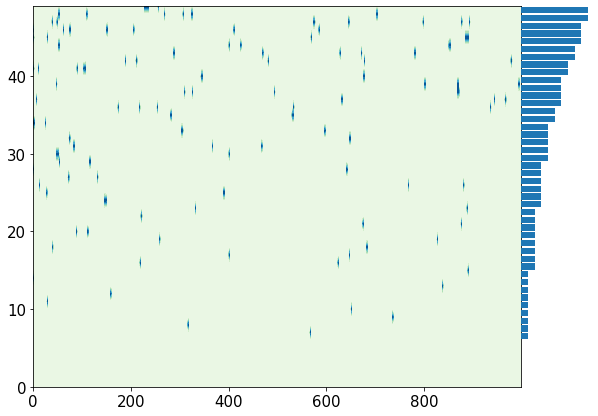

In [89]:
fig, axs = plt.subplots(1, 2, figsize=(10,7), sharey=True, gridspec_kw={'hspace': 0, 
                                                        'wspace': 0,
                                                        'width_ratios': [7, 1],
                                                        'height_ratios': [1]})

cmap = colors.ListedColormap(['green','salmon'])

axs[1].axis("off")
axs[0].contourf(X, Y, z[index_sort, :], cmap='GnBu')
axs[1].barh(np.array(range(len(horzSum)))-0.5, horzSum[index_sort])
axs[1].set_ylim(0.0, 49)

In [90]:
from matplotlib.ticker import FormatStrFormatter

In [91]:
formatter = FormatStrFormatter('%.1f')

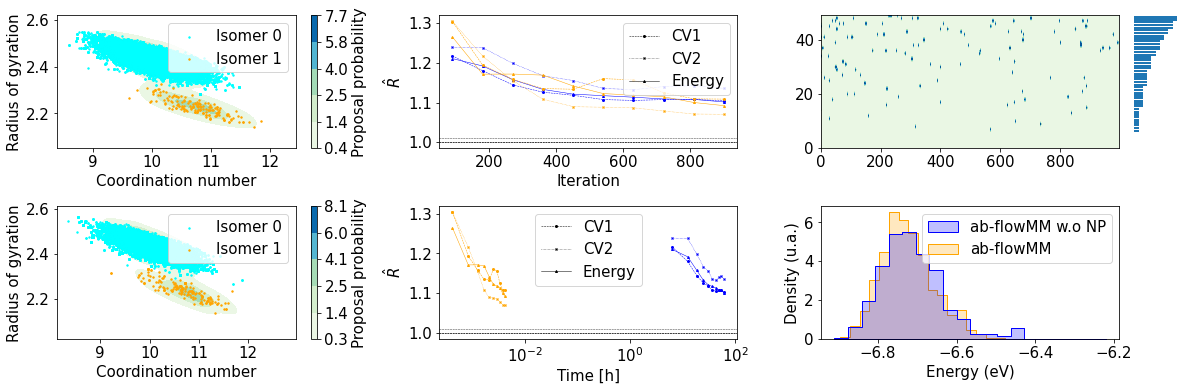

In [92]:
fig = plt.figure()

gs = fig.add_gridspec(2, 3)

axs = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])]

# PLOT collective variablesz
for i, key in enumerate(cvs_mcmcs.keys()):
    sns.kdeplot(data=data_proposals[key], x='Radius of gyration', y='Coordination number', 
                fill=True, cmap='GnBu', ax=axs[i], cbar=True, 
                levels=6,  cbar_kws={'label': 'Proposal probability', 'format': formatter})
    for k in range(2):
        axs[i].scatter(cvs_mcmcs[key][isomers[key]==k][:, 0].flatten().detach(), 
                cvs_mcmcs[key][isomers[key]==k][:, 1].flatten().detach(), 
                s=markersize, 
                color=isomer_colors[k], 
                label='Isomer {:d}'.format(k))
    axs[i].set_xlabel('Coordination number')
    axs[i].set_ylabel('Radius of gyration')
    axs[i].legend(loc='upper right')

axs_rhat = [fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])]

markers = ['o', 'x', '^']
linestyles = ['dashed', 'dotted', '-']

for key in rhat.keys():
        for i in range(rhat[key][0].shape[-1]):
            axs_rhat[0].plot(rhat[key][1], 
                            rhat[key][0][:, i], 
                            linestyle=linestyles[i], 
                            marker=markers[i],
                            markersize=markersize,
                            linewidth=linewidth,
                            color=color_keys[key], 
                            label=rhat[key][2][i])

            axs_rhat[1].plot(time_sims[key][rhat[key][1]],
                            rhat[key][0][:, i],
                            linestyle=linestyles[i], 
                            marker=markers[i],
                            markersize=markersize,
                            linewidth=linewidth,
                            color=color_keys[key], 
                            label=rhat[key][2][i])
        
        axs_rhat[1].set_xlabel('Time [h]')
        axs_rhat[1].set_ylabel(r'$\hat{R}$')
        axs_rhat[1].axhline(1, c='k', ls='--', linewidth=linewidth)
        axs_rhat[1].axhline(1.01, c='grey', ls='--', linewidth=linewidth)
        axs_rhat[1].set_xscale('log')


        axs_rhat[0].axhline(1, c='k', ls='--', linewidth=linewidth)
        axs_rhat[0].axhline(1.01, c='grey', ls='--', linewidth=linewidth)
        axs_rhat[0].set_xlabel('Iteration')
        axs_rhat[0].set_ylabel(r'$\hat{R}$')

for j in range(2):
    colors = ["k"]*3
    patches = [ axs_rhat[j].plot([],[], marker=markers[i], linestyle=linestyles[i], linewidth=linewidth, markersize=markersize, color=colors[i], 
                label="{:s}".format(rhat[key][2][i]) )[0]  for i in range(len(rhat[key][2])) ]
    axs_rhat[j].legend(handles=patches) 

ax_jumps = fig.add_subplot(gs[0, 2])
ax_hists = ax_jumps.inset_axes([1.05, 0, 0.15, 1], sharey=ax_jumps)

ax_hists.axis("off")
ax_jumps.contourf(X, Y, z[index_sort, :], cmap='GnBu')
ax_hists.barh(np.array(range(len(horzSum)))-0.5, horzSum[index_sort])
ax_hists.set_ylim(0.0, 49)

axs_energy = fig.add_subplot(gs[1, 2])

plot_energy_histogram(us, ax=axs_energy, palette=color_keys, bins=20, element='step')

plt.tight_layout()

plt.savefig(path_to_save_figures+'figure_2_mixture.png', dpi=300, facecolor='white', transparent=False)